# DiffusionUNet model Implementation

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
def make_group_norm(channels: int, max_groups: int = 32) -> nn.GroupNorm:
    """
    Creates GroupNorm with a valid number of groups.
    """
    groups = min(max_groups, channels)
    while channels % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, channels)

In [3]:
class SinusoidalTimeEmbedding(nn.Module):
    """
    Converts scalar diffusion timestep t into a sinusoidal embedding.
    """

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        t: [B]
        returns: [B, dim]
        """
        half_dim = self.dim // 2
        device = t.device

        exponent = -math.log(10000) * torch.arange(
            half_dim, device=device, dtype=torch.float32
        ) / max(half_dim - 1, 1)

        freqs = torch.exp(exponent)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)

        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


In [4]:
class TimeMLP(nn.Module):
    """
    Projects sinusoidal timestep embedding into a learned time embedding.
    """

    def __init__(self, emb_dim: int, hidden_dim: int):
        super().__init__()

        self.net = nn.Sequential(
            SinusoidalTimeEmbedding(emb_dim),
            nn.Linear(emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        return self.net(t)


In [5]:
class ResBlock(nn.Module):
    """
    Residual block with timestep conditioning.
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        time_dim: int,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.norm1 = make_group_norm(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_channels)

        self.norm2 = make_group_norm(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        """
        x: [B, C, H, W]
        time_emb: [B, time_dim]
        """
        h = self.conv1(F.silu(self.norm1(x)))

        time_out = self.time_proj(F.silu(time_emb))
        h = h + time_out[:, :, None, None]

        h = self.conv2(self.dropout(F.silu(self.norm2(h))))

        return h + self.shortcut(x)


In [6]:

class AttentionBlock(nn.Module):
    """
    Spatial self-attention block.
    Useful at lower resolutions where H*W is not too large.
    """

    def __init__(self, channels: int, num_heads: int = 4):
        super().__init__()

        if channels % num_heads != 0:
            raise ValueError(
                f"channels={channels} must be divisible by num_heads={num_heads}"
            )

        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = channels // num_heads

        self.norm = make_group_norm(channels)
        self.qkv = nn.Conv2d(channels, channels * 3, kernel_size=1)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, C, H, W]
        """
        b, c, h, w = x.shape

        h_norm = self.norm(x)
        qkv = self.qkv(h_norm)

        qkv = qkv.reshape(
            b,
            3,
            self.num_heads,
            self.head_dim,
            h * w,
        )

        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]

        scale = self.head_dim ** -0.5
        attn = torch.einsum("bhdn,bhdm->bhnm", q * scale, k)
        attn = attn.softmax(dim=-1)

        out = torch.einsum("bhnm,bhdm->bhdn", attn, v)
        out = out.reshape(b, c, h, w)

        return x + self.proj(out)

In [7]:
class Downsample(nn.Module):
    """
    Reduces spatial resolution by 2.
    """

    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            stride=2,
            padding=1,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class Upsample(nn.Module):
    """
    Increases spatial resolution by 2.
    """

    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)


In [5]:
class DiffusionUNet(nn.Module):
    """
    U-Net for diffusion noise prediction.

    Input:
        x: [B, C, H, W]
        t: [B]

    Output:
        predicted noise with same shape as x
    """

    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        base_channels=64,
        channel_mults=(1, 2, 4),
        num_res_blocks=2,
        time_emb_dim=256,
        attention_levels=(2,),
        num_heads=4,
        dropout=0.0,
    ):
        super().__init__()

        self.time_mlp = TimeMLP(
            emb_dim=base_channels,
            hidden_dim=time_emb_dim,
        )

        self.init_conv = nn.Conv2d(
            in_channels,
            base_channels,
            kernel_size=3,
            padding=1,
        )

        # Encoder
        self.downs = nn.ModuleList()
        skip_channels = []

        current_channels = base_channels

        for level, mult in enumerate(channel_mults):
            out_channels_level = base_channels * mult

            for _ in range(num_res_blocks):
                self.downs.append(
                    nn.ModuleList([
                        ResBlock(
                            current_channels,
                            out_channels_level,
                            time_dim=time_emb_dim,
                            dropout=dropout,
                        ),
                        AttentionBlock(out_channels_level, num_heads)
                        if level in attention_levels
                        else nn.Identity(),
                    ])
                )

                current_channels = out_channels_level
                skip_channels.append(current_channels)

            if level != len(channel_mults) - 1:
                self.downs.append(Downsample(current_channels))

        # Bottleneck
        self.mid_block1 = ResBlock(
            current_channels,
            current_channels,
            time_dim=time_emb_dim,
            dropout=dropout,
        )

        self.mid_attn = AttentionBlock(current_channels, num_heads)

        self.mid_block2 = ResBlock(
            current_channels,
            current_channels,
            time_dim=time_emb_dim,
            dropout=dropout,
        )

        # Decoder
        self.ups = nn.ModuleList()

        for level, mult in reversed(list(enumerate(channel_mults))):
            out_channels_level = base_channels * mult

            for _ in range(num_res_blocks):
                skip_ch = skip_channels.pop()

                self.ups.append(
                    nn.ModuleList([
                        ResBlock(
                            current_channels + skip_ch,
                            out_channels_level,
                            time_dim=time_emb_dim,
                            dropout=dropout,
                        ),
                        AttentionBlock(out_channels_level, num_heads)
                        if level in attention_levels
                        else nn.Identity(),
                    ])
                )

                current_channels = out_channels_level

            if level != 0:
                self.ups.append(Upsample(current_channels))

        self.final_norm = make_group_norm(current_channels)

        self.final_conv = nn.Conv2d(
            current_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

    def forward(self, x, t):
        time_emb = self.time_mlp(t)

        x = self.init_conv(x)

        skips = []

        # Encoder
        for layer in self.downs:
            if isinstance(layer, nn.ModuleList):
                res_block, attn = layer

                x = res_block(x, time_emb)
                x = attn(x)

                skips.append(x)
            else:
                x = layer(x)

        # Bottleneck
        x = self.mid_block1(x, time_emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, time_emb)

        # Decoder
        for layer in self.ups:
            if isinstance(layer, nn.ModuleList):
                skip = skips.pop()

                if x.shape[-2:] != skip.shape[-2:]:
                    x = F.interpolate(
                        x,
                        size=skip.shape[-2:],
                        mode="nearest",
                    )

                x = torch.cat([x, skip], dim=1)

                res_block, attn = layer
                x = res_block(x, time_emb)
                x = attn(x)

            else:
                x = layer(x)

        x = self.final_conv(F.silu(self.final_norm(x)))

        return x

In [10]:
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

source_root = Path("stargan-v2/data")
target_root = Path("data/afhq_64")

if not source_root.exists():
    raise FileNotFoundError(f"Dataset path not found: {source_root}")

target_root.mkdir(parents=True, exist_ok=True)

image_paths = []

# Train images
train_dir = source_root / "train"
if train_dir.exists():
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        image_paths.extend(train_dir.rglob(ext))

# Test images
test_dir = source_root / "test"
if test_dir.exists():
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        image_paths.extend(test_dir.rglob(ext))

print("Source:", source_root)
print("Target:", target_root)
print("Found images:", len(image_paths))

if len(image_paths) == 0:
    raise RuntimeError("No images found inside stargan-v2/data/train or stargan-v2/data/test")

try:
    resample_method = Image.Resampling.LANCZOS
except AttributeError:
    resample_method = Image.LANCZOS

for img_path in tqdm(image_paths):
    relative_path = img_path.relative_to(source_root)

    save_path = target_root / relative_path
    save_path = save_path.with_suffix(".png")

    save_path.parent.mkdir(parents=True, exist_ok=True)

    img = Image.open(img_path).convert("RGB")
    img = img.resize((64, 64), resample_method)
    img.save(save_path)

print("Saved 64x64 dataset to:", target_root)

Source: stargan-v2/data
Target: data/afhq_64
Found images: 15803


  0%|          | 0/15803 [00:00<?, ?it/s]

Saved 64x64 dataset to: data/afhq_64


In [9]:
train_root = "data/afhq_64/train"
test_root = "data/afhq_64/test"

In [10]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

train_dataset = datasets.ImageFolder(
    root=train_root,
    transform=transform,
)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2 if os.name != "nt" else 0,
    pin_memory=True,
    drop_last=True,
)

images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Classes:", train_dataset.classes)

Images: torch.Size([32, 3, 64, 64])
Labels: torch.Size([32])
Classes: ['cat', 'dog', 'wild']


In [11]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

T = 1000

def linear_beta_schedule(timesteps):
    beta_start = 1e-4
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(T).to(device)

alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

alphas_cumprod_prev = torch.cat([
    torch.tensor([1.0], device=device),
    alphas_cumprod[:-1],
])

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (
    1.0 - alphas_cumprod_prev
) / (
    1.0 - alphas_cumprod
)


def extract(values, t, x_shape):
    """
    values: [T]
    t: [B]
    returns: [B, 1, 1, 1]
    """
    batch_size = t.shape[0]
    out = values.gather(0, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))


def q_sample(x_start, t, noise=None):
    """
    Forward diffusion:
    q(x_t | x_0) = sqrt(alpha_bar_t) x_0 + sqrt(1 - alpha_bar_t) noise
    """
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alpha_bar_t = extract(
        sqrt_one_minus_alphas_cumprod,
        t,
        x_start.shape,
    )

    return sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise

Device: cuda


In [ ]:
model = DiffusionUNet(
    in_channels=3,
    out_channels=3,
    base_channels=64,
    channel_mults=(1, 2, 4),
    num_res_blocks=2,
    time_emb_dim=256,
    attention_levels=(2,),
    num_heads=4,
    dropout=0.1,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

In [13]:
x = torch.randn(4, 3, 64, 64).to(device)
t = torch.randint(0, 1000, (4,), device=device)

with torch.no_grad():
    y = model(x, t)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

Input shape: torch.Size([4, 3, 64, 64])
Output shape: torch.Size([4, 3, 64, 64])


In [14]:
from pathlib import Path
from tqdm.auto import tqdm

checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)

epochs = 30
log_every = 50

global_step = 0

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")

    for step, (x_start, _) in enumerate(progress):
        x_start = x_start.to(device, non_blocking=True)

        batch_size = x_start.shape[0]

        t = torch.randint(
            low=0,
            high=T,
            size=(batch_size,),
            device=device,
            dtype=torch.long,
        )

        noise = torch.randn_like(x_start)
        x_noisy = q_sample(x_start=x_start, t=t, noise=noise)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda"),
        ):
            predicted_noise = model(x_noisy, t)
            loss = F.mse_loss(predicted_noise, noise)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        global_step += 1

        if step % log_every == 0:
            progress.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch} | Average loss: {avg_loss:.6f}")

    checkpoint_path = checkpoint_dir / f"afhq_ddpm_epoch_{epoch:03d}.pt"

    torch.save(
        {
            "epoch": epoch,
            "global_step": global_step,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": avg_loss,
            "T": T,
        },
        checkpoint_path,
    )

    print("Saved:", checkpoint_path)

Epoch 1/30:   0%|          | 0/448 [00:00<?, ?it/s]

Epoch 1 | Average loss: 0.080622
Saved: checkpoints/afhq_ddpm_epoch_001.pt


Epoch 2/30:   0%|          | 0/448 [00:00<?, ?it/s]

Epoch 2 | Average loss: 0.045121
Saved: checkpoints/afhq_ddpm_epoch_002.pt


Epoch 3/30:   0%|          | 0/448 [00:00<?, ?it/s]

...

Epoch 28 | Average loss: 0.031429
Saved: checkpoints/afhq_ddpm_epoch_028.pt


Epoch 29/30:   0%|          | 0/448 [00:00<?, ?it/s]

Epoch 29 | Average loss: 0.030866
Saved: checkpoints/afhq_ddpm_epoch_029.pt


Epoch 30/30:   0%|          | 0/448 [00:00<?, ?it/s]

Epoch 30 | Average loss: 0.031543
Saved: checkpoints/afhq_ddpm_epoch_030.pt


In [16]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image

@torch.no_grad()
def p_sample(model, x, t, t_index):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod,
        t,
        x.shape,
    )
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    predicted_noise = model(x, t)

    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean

    posterior_variance_t = extract(posterior_variance, t, x.shape)
    noise = torch.randn_like(x)

    return model_mean + torch.sqrt(posterior_variance_t) * noise


@torch.no_grad()
def sample(model, batch_size=16, channels=3, image_size=64):
    model.eval()

    x = torch.randn(
        batch_size,
        channels,
        image_size,
        image_size,
        device=device,
    )

    for t_index in tqdm(reversed(range(T)), total=T, desc="Sampling"):
        t = torch.full(
            size=(batch_size,),
            fill_value=t_index,
            device=device,
            dtype=torch.long,
        )
        x = p_sample(model, x, t, t_index)

    x = x.clamp(-1, 1)
    return x

Matplotlib is building the font cache; this may take a moment.


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

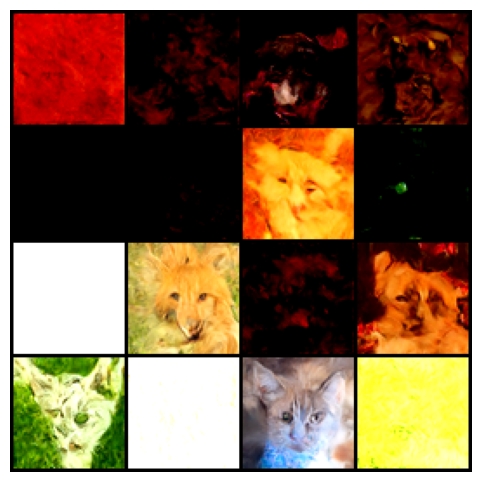

In [17]:
samples = sample(
    model,
    batch_size=16,
    channels=3,
    image_size=64,
)

samples_for_display = (samples + 1) / 2
samples_for_display = samples_for_display.clamp(0, 1)

grid = make_grid(samples_for_display, nrow=4)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.show()

Path("samples").mkdir(exist_ok=True)
save_image(samples_for_display, "samples/afhq_generated.png", nrow=4)

# Load Checkpoint

In [4]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def make_group_norm(channels, max_groups=32):
    groups = min(max_groups, channels)
    while channels % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, channels)


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        device = t.device

        exponent = -math.log(10000) * torch.arange(
            half_dim, device=device, dtype=torch.float32
        ) / max(half_dim - 1, 1)

        freqs = torch.exp(exponent)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)

        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


class TimeMLP(nn.Module):
    def __init__(self, emb_dim, hidden_dim):
        super().__init__()

        self.net = nn.Sequential(
            SinusoidalTimeEmbedding(emb_dim),
            nn.Linear(emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, t):
        return self.net(t)


class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, dropout=0.0):
        super().__init__()

        self.norm1 = make_group_norm(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_channels)

        self.norm2 = make_group_norm(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, time_emb):
        h = self.conv1(F.silu(self.norm1(x)))

        time_out = self.time_proj(F.silu(time_emb))
        h = h + time_out[:, :, None, None]

        h = self.conv2(self.dropout(F.silu(self.norm2(h))))

        return h + self.shortcut(x)


class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()

        if channels % num_heads != 0:
            raise ValueError(
                f"channels={channels} must be divisible by num_heads={num_heads}"
            )

        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = channels // num_heads

        self.norm = make_group_norm(channels)
        self.qkv = nn.Conv2d(channels, channels * 3, kernel_size=1)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        b, c, h, w = x.shape

        x_norm = self.norm(x)
        qkv = self.qkv(x_norm)

        qkv = qkv.reshape(
            b,
            3,
            self.num_heads,
            self.head_dim,
            h * w,
        )

        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]

        scale = self.head_dim ** -0.5
        attn = torch.einsum("bhdn,bhdm->bhnm", q * scale, k)
        attn = attn.softmax(dim=-1)

        out = torch.einsum("bhnm,bhdm->bhdn", attn, v)
        out = out.reshape(b, c, h, w)

        return x + self.proj(out)


class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            stride=2,
            padding=1,
        )

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
        )

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)


class DiffusionUNet(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        base_channels=64,
        channel_mults=(1, 2, 4),
        num_res_blocks=2,
        time_emb_dim=256,
        attention_levels=(2,),
        num_heads=4,
        dropout=0.0,
    ):
        super().__init__()

        self.time_mlp = TimeMLP(
            emb_dim=base_channels,
            hidden_dim=time_emb_dim,
        )

        self.init_conv = nn.Conv2d(
            in_channels,
            base_channels,
            kernel_size=3,
            padding=1,
        )

        self.downs = nn.ModuleList()
        skip_channels = []

        current_channels = base_channels

        for level, mult in enumerate(channel_mults):
            out_channels_level = base_channels * mult

            for _ in range(num_res_blocks):
                self.downs.append(
                    nn.ModuleList([
                        ResBlock(
                            current_channels,
                            out_channels_level,
                            time_dim=time_emb_dim,
                            dropout=dropout,
                        ),
                        AttentionBlock(out_channels_level, num_heads)
                        if level in attention_levels
                        else nn.Identity(),
                    ])
                )

                current_channels = out_channels_level
                skip_channels.append(current_channels)

            if level != len(channel_mults) - 1:
                self.downs.append(Downsample(current_channels))

        self.mid_block1 = ResBlock(
            current_channels,
            current_channels,
            time_dim=time_emb_dim,
            dropout=dropout,
        )

        self.mid_attn = AttentionBlock(current_channels, num_heads)

        self.mid_block2 = ResBlock(
            current_channels,
            current_channels,
            time_dim=time_emb_dim,
            dropout=dropout,
        )

        self.ups = nn.ModuleList()

        for level, mult in reversed(list(enumerate(channel_mults))):
            out_channels_level = base_channels * mult

            for _ in range(num_res_blocks):
                skip_ch = skip_channels.pop()

                self.ups.append(
                    nn.ModuleList([
                        ResBlock(
                            current_channels + skip_ch,
                            out_channels_level,
                            time_dim=time_emb_dim,
                            dropout=dropout,
                        ),
                        AttentionBlock(out_channels_level, num_heads)
                        if level in attention_levels
                        else nn.Identity(),
                    ])
                )

                current_channels = out_channels_level

            if level != 0:
                self.ups.append(Upsample(current_channels))

        self.final_norm = make_group_norm(current_channels)

        self.final_conv = nn.Conv2d(
            current_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

    def forward(self, x, t):
        time_emb = self.time_mlp(t)

        x = self.init_conv(x)
        skips = []

        for layer in self.downs:
            if isinstance(layer, nn.ModuleList):
                res_block, attn = layer
                x = res_block(x, time_emb)
                x = attn(x)
                skips.append(x)
            else:
                x = layer(x)

        x = self.mid_block1(x, time_emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, time_emb)

        for layer in self.ups:
            if isinstance(layer, nn.ModuleList):
                skip = skips.pop()

                if x.shape[-2:] != skip.shape[-2:]:
                    x = F.interpolate(
                        x,
                        size=skip.shape[-2:],
                        mode="nearest",
                    )

                x = torch.cat([x, skip], dim=1)

                res_block, attn = layer
                x = res_block(x, time_emb)
                x = attn(x)
            else:
                x = layer(x)

        x = self.final_conv(F.silu(self.final_norm(x)))

        return x

In [23]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = "checkpoints/afhq_ddpm_epoch_100.pt"

checkpoint = torch.load(checkpoint_path, map_location=device)

model = DiffusionUNet(
    in_channels=3,
    out_channels=3,
    base_channels=64,
    channel_mults=(1, 2, 4),
    num_res_blocks=2,
    time_emb_dim=256,
    attention_levels=(2,),
    num_heads=4,
    dropout=0.1,
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Loaded checkpoint from epoch:", checkpoint["epoch"])
print("Checkpoint loss:", checkpoint["loss"])

Loaded checkpoint from epoch: 100
Checkpoint loss: 0.02910646256558331


# Test

In [27]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

In [28]:
test_root = "data/afhq_64/test"

In [29]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

test_dataset = datasets.ImageFolder(
    root=test_root,
    transform=transform,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2 if os.name != "nt" else 0,
    pin_memory=True,
    drop_last=False,
)

print("Test images:", len(test_dataset))
print("Classes:", test_dataset.classes)

x_test, y_test = next(iter(test_loader))
print("Batch images:", x_test.shape)
print("Batch labels:", y_test.shape)

Test images: 1467
Classes: ['cat', 'dog', 'wild']
Batch images: torch.Size([32, 3, 64, 64])
Batch labels: torch.Size([32])


In [30]:
@torch.no_grad()
def evaluate_diffusion_loss(model, test_loader):
    model.eval()
    total_loss = 0.0

    for x_start, _ in test_loader:
        x_start = x_start.to(device, non_blocking=True)

        batch_size = x_start.shape[0]

        t = torch.randint(
            low=0,
            high=T,
            size=(batch_size,),
            device=device,
            dtype=torch.long,
        )

        noise = torch.randn_like(x_start)
        x_noisy = q_sample(x_start=x_start, t=t, noise=noise)

        predicted_noise = model(x_noisy, t)
        loss = F.mse_loss(predicted_noise, noise)

        total_loss += loss.item()

    return total_loss / len(test_loader)




In [31]:
import torch


# Use T from checkpoint if available, otherwise default to 1000
T = checkpoint.get("T", 1000)

def linear_beta_schedule(timesteps):
    beta_start = 1e-4
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(T).to(device)

alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

alphas_cumprod_prev = torch.cat([
    torch.tensor([1.0], device=device),
    alphas_cumprod[:-1],
])

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (
    1.0 - alphas_cumprod_prev
) / (
    1.0 - alphas_cumprod
)


def extract(values, t, x_shape):
    batch_size = t.shape[0]
    out = values.gather(0, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))


def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alpha_bar_t = extract(
        sqrt_one_minus_alphas_cumprod,
        t,
        x_start.shape,
    )

    return sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise

In [32]:
test_loss = evaluate_diffusion_loss(model, test_loader)
print("Diffusion test loss:", test_loss)

Diffusion test loss: 0.02921535157720032


# Generate New Images

In [33]:
from tqdm.auto import tqdm
import torch


In [34]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image

@torch.no_grad()
def p_sample(model, x, t, t_index):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod,
        t,
        x.shape,
    )
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    predicted_noise = model(x, t)

    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean

    posterior_variance_t = extract(posterior_variance, t, x.shape)
    noise = torch.randn_like(x)

    return model_mean + torch.sqrt(posterior_variance_t) * noise


@torch.no_grad()
def generate_samples(model, batch_size=16, image_size=64):
    model.eval()

    x = torch.randn(
        batch_size,
        3,
        image_size,
        image_size,
        device=device,
    )

    for t_index in tqdm(reversed(range(T)), total=T, desc="Generating"):
        t = torch.full(
            (batch_size,),
            t_index,
            device=device,
            dtype=torch.long,
        )

        x = p_sample(model, x, t, t_index)

    x = x.clamp(-1, 1)
    return x

Generating:   0%|          | 0/1000 [00:00<?, ?it/s]

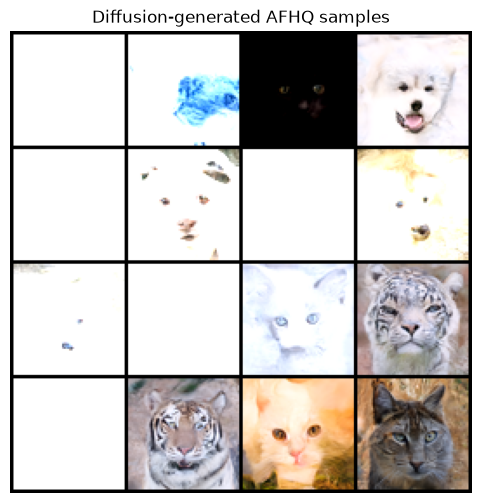

In [35]:
samples = generate_samples(model, batch_size=16)

samples_display = (samples + 1) / 2
samples_display = samples_display.clamp(0, 1)

grid = make_grid(samples_display, nrow=4)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Diffusion-generated AFHQ samples")
plt.show()

save_image(samples_display, "diffusion_generated_afhq.png", nrow=4)

## Comparison Between Autoencoder and Diffusion Model Results

Both models were trained on the AFHQ 64×64 animal face dataset, but they generate images in different ways.

The autoencoder generates new images by sampling latent vectors and passing them through the decoder. The diffusion model generates images by starting from random Gaussian noise and gradually denoising it through the learned reverse diffusion process.

### Autoencoder Results

The autoencoder results show that the model learned a smooth latent representation of animal faces. The generated samples contain animal-like colors and rough face structures, but the images are generally blurry and lack fine details.

Different values of `beta` affected the quality of the generated samples:

| Beta value | Observation |
|---|---|
| `1e-06` | Samples contain noisy textures and weak animal structure. |
| `1e-05` | Best autoencoder result. Animal-like faces are more visible, although still blurry. |
| `1e-04` | Images become smoother and less detailed. |
| `1e-03` | Too much regularization. Samples collapse into very blurry, averaged shapes. |

The best autoencoder result was obtained with `beta = 1e-05`, which gave the clearest balance between latent-space regularization and visual structure.

### Diffusion Model Results

The diffusion model produced less consistent results than the autoencoder, but some generated samples were sharper and more realistic. Several samples showed recognizable animal faces, such as cats, dogs, and wild animals.

However, the diffusion model also produced some failed samples, including blank, overexposed, black, or noisy images.
### Visual Quality Comparison

| Criterion | Autoencoder | Diffusion Model |
|---|---|---|
| Generation method | Sample latent vector and decode | Start from Gaussian noise and denoise |
| Image sharpness | Blurry | Sharper when successful |
| Stability | More consistent | Less stable |
| Failure mode | Smooth blurry faces | Blank, saturated, or noisy samples |
| Latent space | Explicit latent space | No explicit encoder latent space |
| Interpolation | Easy latent-vector interpolation | Noise-space interpolation |
| Sampling speed | Fast | Slow because many denoising steps are required |
| Best result | Consistent but blurry animal-like images | Some sharper and more realistic animal faces |

### Main Discussion

The autoencoder is easier to train and produces more consistent outputs. Since it has an explicit latent space, it is also easier to investigate the latent representation and visualize interpolations between samples. However, the generated images are blurry because the model is mainly optimized for reconstruction.

The diffusion model is harder to train and slower during generation, but it has better potential image quality. In the generated samples, some animal faces are sharper and more realistic than the autoencoder outputs. However, the diffusion results are less stable, with several failed samples. This shows that diffusion models usually require longer training and careful sampling to achieve high-quality results.

### Conclusion

The autoencoder produced more stable but blurrier samples, while the diffusion model produced less stable but sometimes sharper and more realistic samples. For this experiment, the autoencoder was better for latent-space analysis and interpolation, while the diffusion model showed better potential for high-quality image generation after sufficient training.

Overall, the results show the typical trade-off between the two approaches:

- Autoencoders are faster, simpler, and easier to interpret.
- Diffusion models can generate higher-quality images, but they require more training and slower iterative sampling.

# Visualize Denoising Trajectory

Denoising trajectory:   0%|          | 0/1000 [00:00<?, ?it/s]

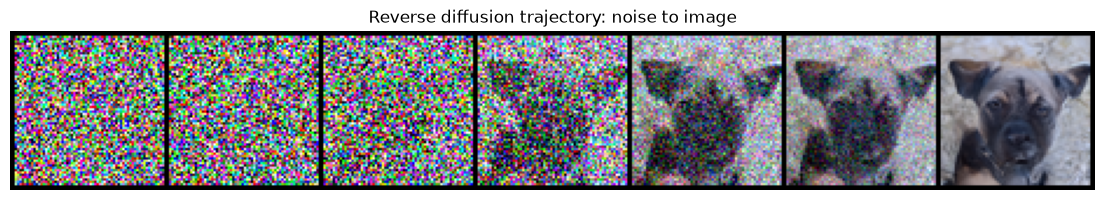

In [37]:
@torch.no_grad()
def denoising_trajectory(
    model,
    image_size=64,
    save_steps=(999, 750, 500, 250, 100, 50, 0),
):
    model.eval()

    x = torch.randn(1, 3, image_size, image_size, device=device)
    saved_images = []

    for t_index in tqdm(reversed(range(T)), total=T, desc="Denoising trajectory"):
        t = torch.full(
            (1,),
            t_index,
            device=device,
            dtype=torch.long,
        )

        x = p_sample(model, x, t, t_index)

        if t_index in save_steps:
            img = x.clamp(-1, 1)
            img = (img + 1) / 2
            saved_images.append(img.squeeze(0).cpu())

    return saved_images


trajectory = denoising_trajectory(model)

grid = make_grid(trajectory, nrow=len(trajectory))

plt.figure(figsize=(14, 3))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Reverse diffusion trajectory: noise to image")
plt.show()

## Denoising Trajectory and Interpolation Comparison

### Diffusion Denoising Trajectory

The diffusion model shows a clear reverse denoising process. The image starts as pure Gaussian noise and gradually becomes more structured as the timestep decreases. In the final step, the model produces a recognizable animal face, in this case a dog.

This result shows that the diffusion model has learned the basic reverse process.

The intermediate images are useful because they show how the model gradually removes noise and adds semantic structure. Unlike the autoencoder, the diffusion model does not generate the image in one step. It requires many denoising steps, which makes generation slower but allows the model to progressively refine the image.


# Interpolate 

In [38]:
def slerp(alpha, x1, x2):
    x1_flat = x1.reshape(x1.shape[0], -1)
    x2_flat = x2.reshape(x2.shape[0], -1)

    x1_norm = F.normalize(x1_flat, dim=1)
    x2_norm = F.normalize(x2_flat, dim=1)

    dot = (x1_norm * x2_norm).sum(dim=1).clamp(-0.999, 0.999)
    theta = torch.acos(dot)

    sin_theta = torch.sin(theta)

    a = torch.sin((1 - alpha) * theta) / sin_theta
    b = torch.sin(alpha * theta) / sin_theta

    out = a[:, None] * x1_flat + b[:, None] * x2_flat

    return out.reshape_as(x1)


@torch.no_grad()
def diffusion_interpolation(model, steps=8, image_size=64):
    model.eval()

    noise_a = torch.randn(1, 3, image_size, image_size, device=device)
    noise_b = torch.randn(1, 3, image_size, image_size, device=device)

    noises = []

    for alpha in torch.linspace(0, 1, steps, device=device):
        noise_interp = slerp(alpha, noise_a, noise_b)
        noises.append(noise_interp)

    x = torch.cat(noises, dim=0)

    for t_index in tqdm(reversed(range(T)), total=T, desc="Interpolating"):
        t = torch.full(
            (steps,),
            t_index,
            device=device,
            dtype=torch.long,
        )

        x = p_sample(model, x, t, t_index)

    x = x.clamp(-1, 1)
    return x

Interpolating:   0%|          | 0/1000 [00:00<?, ?it/s]

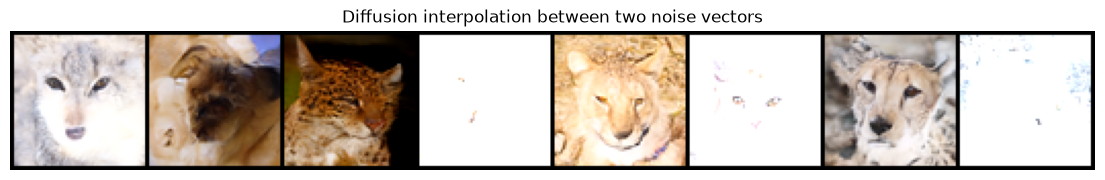

In [39]:
interp_samples = diffusion_interpolation(model, steps=8)

interp_display = (interp_samples + 1) / 2
interp_display = interp_display.clamp(0, 1)

grid = make_grid(interp_display, nrow=8)

plt.figure(figsize=(14, 3))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Diffusion interpolation between two noise vectors")
plt.show()

save_image(interp_display, "diffusion_noise_interpolation.png", nrow=8)

## Interpolation Comparison: Autoencoder vs Diffusion Model

### Autoencoder Interpolation

The autoencoder gives smoother and more interpretable interpolation results because it has an explicit latent space. Each image is encoded into a latent vector `z`, and interpolation is performed directly between two latent vectors.

The decoder then maps each interpolated latent vector back into an image.

In the results, the autoencoder interpolation changes gradually from one image to another. For example, in cat-to-dog interpolation, the face shape, colors, and features slowly change from cat-like to dog-like. This shows that the latent space has learned a meaningful structure.

However, the interpolated images are blurry, especially for larger beta values. Higher beta values make the latent space smoother and more regular, but they reduce visual detail.

### Diffusion Interpolation

The diffusion model does not have an explicit encoder latent space like the autoencoder. Instead, interpolation is done between two initial noise tensors.

Each interpolated noise tensor is then passed through the reverse diffusion process.

In the diffusion interpolation result, the transitions are less smooth than the autoencoder interpolation. Some samples become recognizable animal faces, but others become blank, overexposed, or unstable. This happens because diffusion interpolation is performed in noise space, which is less directly interpretable than the autoencoder latent space.

Also, if standard DDPM sampling is used, the reverse process adds random noise at each step. This randomness can make the interpolation less continuous. A deterministic sampler such as DDIM would usually give smoother diffusion interpolations.

### Comparison Table

| Criterion | Autoencoder | Diffusion Model |
|---|---|---|
| Interpolation space | Explicit latent space `z` | Initial noise space `x_T` |
| Smoothness | Smooth and gradual | Less smooth, more unstable |
| Interpretability | Easier to interpret | Harder to interpret |
| Visual quality | Blurry but consistent | Sharper when successful, but inconsistent |
| Failure mode | Over-smoothed images | Blank, saturated, or unrelated samples |
| Sampling cost | Fast, one decoder pass per image | Slow, full reverse denoising per image |
| Best use | Latent-space analysis | Generative sampling and denoising visualization |

### Conclusion

The autoencoder performs better for interpolation because its latent space is explicit, compact, and easier to manipulate. The interpolations are smooth and show gradual semantic changes between images, although the outputs are blurry.

The diffusion model can produce sharper individual samples, but its interpolation is less stable because it interpolates between noise tensors rather than semantic latent vectors. In the shown results, diffusion interpolation produces some realistic animal faces, but the transition is not smooth and includes failed samples.

Overall, the autoencoder is better for latent-space interpolation and interpretability, while the diffusion model is better for high-quality generation. For smoother diffusion interpolation, a deterministic DDIM sampler would be more suitable than stochastic DDPM sampling.

# Continue Training

This code was to continue training from 30 epochs to 100 epochs as 30 epochs showed poor results

The results of 100 epochs are shown above.

In [18]:
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = "checkpoints/afhq_ddpm_epoch_030.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

model = DiffusionUNet(
    in_channels=3,
    out_channels=3,
    base_channels=64,
    channel_mults=(1, 2, 4),
    num_res_blocks=2,
    time_emb_dim=256,
    attention_levels=(2,),
    num_heads=4,
    dropout=0.1,
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"] + 1
global_step = checkpoint["global_step"]

print("Loaded checkpoint from epoch:", checkpoint["epoch"])
print("Resume from epoch:", start_epoch)
print("Previous loss:", checkpoint["loss"])

Loaded checkpoint from epoch: 30
Resume from epoch: 31
Previous loss: 0.03154252589281116


In [19]:
T = checkpoint.get("T", 1000)

def linear_beta_schedule(timesteps):
    beta_start = 1e-4
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(T).to(device)

alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

alphas_cumprod_prev = torch.cat([
    torch.tensor([1.0], device=device),
    alphas_cumprod[:-1],
])

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (
    1.0 - alphas_cumprod_prev
) / (
    1.0 - alphas_cumprod
)


def extract(values, t, x_shape):
    batch_size = t.shape[0]
    out = values.gather(0, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))


def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alpha_bar_t = extract(
        sqrt_one_minus_alphas_cumprod,
        t,
        x_start.shape,
    )

    return sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise

In [21]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

train_root = "data/afhq_64/train"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

train_dataset = datasets.ImageFolder(
    root=train_root,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2 if os.name != "nt" else 0,
    pin_memory=True,
    drop_last=True,
)

print("Train images:", len(train_dataset))
print("Classes:", train_dataset.classes)

x_train, y_train = next(iter(train_loader))
print("Batch images:", x_train.shape)
print("Batch labels:", y_train.shape)

Train images: 14336
Classes: ['cat', 'dog', 'wild']
Batch images: torch.Size([32, 3, 64, 64])
Batch labels: torch.Size([32])


In [22]:
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)

target_epochs = 100
log_every = 50

for epoch in range(start_epoch, target_epochs + 1):
    model.train()
    running_loss = 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{target_epochs}")

    for step, (x_start, _) in enumerate(progress):
        x_start = x_start.to(device, non_blocking=True)

        batch_size = x_start.shape[0]

        t = torch.randint(
            low=0,
            high=T,
            size=(batch_size,),
            device=device,
            dtype=torch.long,
        )

        noise = torch.randn_like(x_start)
        x_noisy = q_sample(x_start=x_start, t=t, noise=noise)

        optimizer.zero_grad(set_to_none=True)

        # Full FP32 training: safer for TITAN X Pascal
        predicted_noise = model(x_noisy, t)
        loss = F.mse_loss(predicted_noise, noise)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        global_step += 1

        if step % log_every == 0:
            progress.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch} | Average loss: {avg_loss:.6f}")

    checkpoint_path = checkpoint_dir / f"afhq_ddpm_epoch_{epoch:03d}.pt"

    torch.save(
        {
            "epoch": epoch,
            "global_step": global_step,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": avg_loss,
            "T": T,
        },
        checkpoint_path,
    )

    print("Saved:", checkpoint_path)

Epoch 31/100:   0%|          | 0/448 [00:00<?, ?it/s]

Epoch 31 | Average loss: 0.031595
Saved: checkpoints/afhq_ddpm_epoch_031.pt


Epoch 32/100:   0%|          | 0/448 [00:00<?, ?it/s]

Epoch 32 | Average loss: 0.030197
Saved: checkpoints/afhq_ddpm_epoch_032.pt


Epoch 33/100:   0%|          | 0/448 [00:00<?, ?it/s]

...

Epoch 98 | Average loss: 0.028722
Saved: checkpoints/afhq_ddpm_epoch_098.pt


Epoch 99/100:   0%|          | 0/448 [00:00<?, ?it/s]

Epoch 99 | Average loss: 0.029174
Saved: checkpoints/afhq_ddpm_epoch_099.pt


Epoch 100/100:   0%|          | 0/448 [00:00<?, ?it/s]

Epoch 100 | Average loss: 0.029106
Saved: checkpoints/afhq_ddpm_epoch_100.pt
